In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix

In [54]:
df=pd.read_csv("Telco_customer_churn.csv")
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [55]:
df.shape

(7043, 33)

In [56]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [57]:
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [58]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [59]:
df['Churn Value'] #target variable

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64

In [60]:
columns_to_drop=['CustomerID','Count','Country','State','City','Zip Code','Lat Long','Latitude','Longitude','Churn Label','Churn Score','Churn Reason','CLTV']
df=df.drop(columns=columns_to_drop)

In [61]:
df.shape

(7043, 20)

In [62]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value'],
      dtype='object')

In [63]:
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')

In [64]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [65]:
df['Total Charges'].fillna(df['Total Charges'].median(),inplace=True)

C:\Users\nimra\AppData\Local\Temp\ipykernel_21312\438151978.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Charges'].fillna(df['Total Charges'].median(),inplace=True)


In [66]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [68]:
df.dtypes

Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Value            int64
dtype: object

In [70]:
df.duplicated().sum()

np.int64(22)

In [74]:
df=df.drop_duplicates()

In [75]:
df.duplicated().sum()

np.int64(0)

In [76]:
df.isnull().sum()

Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Value          0
dtype: int64

In [77]:
df['Churn Value'].value_counts() 

Churn Value
0    5164
1    1857
Name: count, dtype: int64

In [80]:
df['Churn Value'].count()

np.int64(7021)

In [86]:
contract_churn=df.groupby(['Churn Value','Contract']).size().unstack()

<Axes: xlabel='Churn Value'>

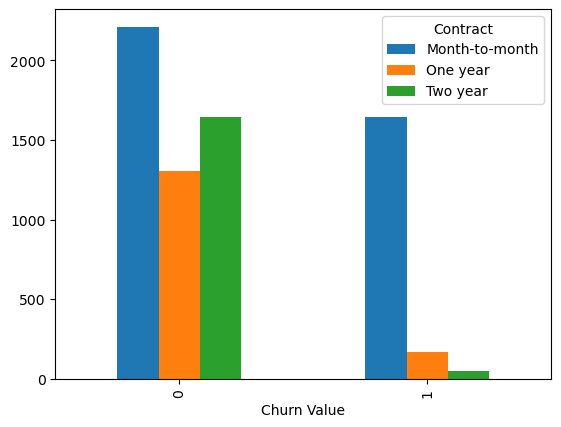

In [87]:
contract_churn.plot(kind='bar')

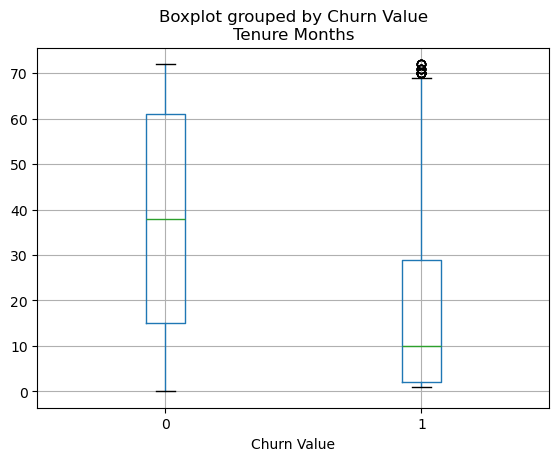

In [94]:
df.boxplot(column='Tenure Months',by='Churn Value')
plt.show()

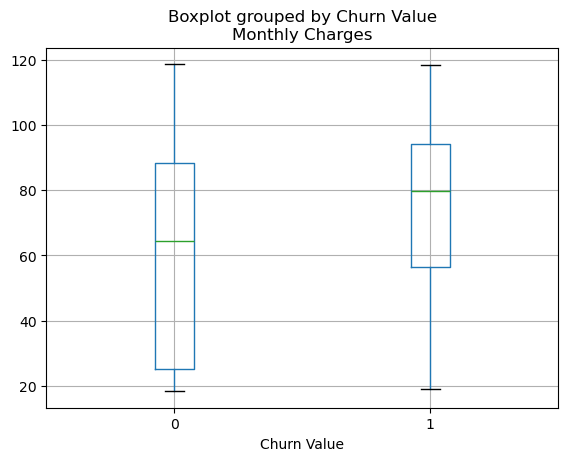

In [98]:
df.boxplot(column='Monthly Charges',by='Churn Value')
plt.show()

In [99]:
payment_churn=df.groupby(['Payment Method','Churn Value']).size().unstack()

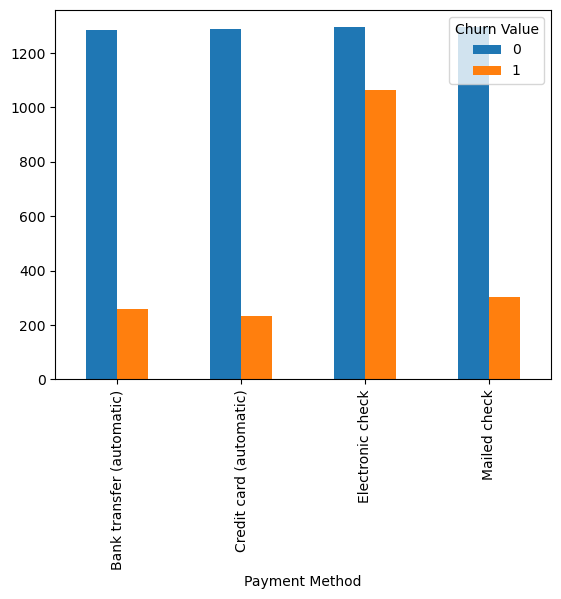

In [100]:
payment_churn.plot(kind='bar')
plt.show()

In [107]:
def tenure_group(x):
    if x<=12:
        return "New"
    elif x<=36:
        return "Mild"
    else:
        return "Old"
df["Tenure_Group"]=df['Tenure Months'].apply(tenure_group)

Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Value            int64
Tenure_Group          object
dtype: object

In [126]:
df['Tenure Months']=df["Tenure Months"].replace(0,1)
df['Avg_Monthly_spend']=df['Monthly Charges']/df['Tenure Months']

In [127]:
X=df.drop("Churn Value",axis=1)
y=df["Churn Value"]

In [128]:
X=pd.get_dummies(X,drop_first=True)

In [129]:
X.dtypes

Tenure Months                               int64
Monthly Charges                           float64
Total Charges                             float64
Avg_Monthly_spend                         float64
Gender_Male                                  bool
Senior Citizen_Yes                           bool
Partner_Yes                                  bool
Dependents_Yes                               bool
Phone Service_Yes                            bool
Multiple Lines_No phone service              bool
Multiple Lines_Yes                           bool
Internet Service_Fiber optic                 bool
Internet Service_No                          bool
Online Security_No internet service          bool
Online Security_Yes                          bool
Online Backup_No internet service            bool
Online Backup_Yes                            bool
Device Protection_No internet service        bool
Device Protection_Yes                        bool
Tech Support_No internet service             bool


In [130]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [131]:
print(X_train.shape)

(5616, 33)


In [132]:
print(X_test.shape)

(1405, 33)


In [133]:
scaler=StandardScaler()

In [135]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

C:\Users\nimra\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [137]:
model=LogisticRegression(class_weight='balanced')

In [138]:
model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced')

In [139]:
y_pred=model.predict(X_test)

In [144]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
      

[[  26 1007]
 [  14  358]]
              precision    recall  f1-score   support

           0       0.65      0.03      0.05      1033
           1       0.26      0.96      0.41       372

    accuracy                           0.27      1405
   macro avg       0.46      0.49      0.23      1405
weighted avg       0.55      0.27      0.14      1405

